In [1]:
import sys
gems_tco_path = '/Users/joonwonlee/Documents/GEMS_TCO-1/src'
sys.path.append(gems_tco_path)

import numpy as np
import pandas as pd
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from pathlib import Path

from GEMS_TCO import configuration as config
from GEMS_TCO.data_loader import load_data_dynamic_processed


# Stationarity Check: Raw vs Lat-1D Diff vs [1,-1,-1,1] Diff

Compare variance and directional semivariogram for three versions of the data:

- **Raw**: no differencing — baseline
- **Lat-1D**: Z(i,j) = X(i+1,j) - X(i,j)  →  removes lat trend only
- **[1,-1,-1,1]**: Z(i,j) = X(i,j) - X(i+1,j) - X(i,j+1) + X(i+1,j+1)  →  2D product filter

If differencing achieves stationarity, North/South (or West/East) panels should collapse together.

In [2]:
# ── Config ──────────────────────────────────────────────────────────────
YEARS        = ['2024']
MONTH_RANGE  = [7]
LAT_RANGE    = [-3, 2]
LON_RANGE    = [121, 131]

data_load_instance = load_data_dynamic_processed(config.mac_data_load_path)

df_map, ord_mm, nns_map, monthly_mean = data_load_instance.load_maxmin_ordered_data_bymonthyear(
    lat_lon_resolution=[1, 1],
    mm_cond_number=8,
    years_=YEARS,
    months_=MONTH_RANGE,
    lat_range=LAT_RANGE,
    lon_range=LON_RANGE,
    is_whittle=False,   # raw ozone values for stationarity EDA
)
print('df_map keys:', len(df_map))
k0 = list(df_map.keys())[0]
print('sample columns:', list(df_map[k0].columns))
print('NaN in ColumnAmountO3 (first orbit):', df_map[k0]['ColumnAmountO3'].isna().sum())


--- Global Monthly Mean for 2024-7: 257.9726 ---
--- Generating NNS Map for Vecchia (C++ Accelerated) ---
df_map keys: 248
sample columns: ['Latitude', 'Longitude', 'ColumnAmountO3', 'Hours_elapsed', 'Source_Latitude', 'Source_Longitude']
NaN in ColumnAmountO3 (first orbit): 56


In [3]:
# ── Three differencing transforms ───────────────────────────────────────
import re

def _parse_key_date(key: str):
    """Parse timestamp from key like '2024_07_y24m07day01_hm00:53'."""
    m = re.search(r'(\d{4})_(\d{2})_y\d+m\d+day(\d+)_hm(\d+):(\d+)', key)
    if m:
        yr, mo, dy, hr, mn = [int(x) for x in m.groups()]
        return pd.Timestamp(yr, mo, dy, hr, mn)
    return pd.NaT


def _grid_diff(df_map_in: dict, kernel: torch.Tensor, name: str) -> dict:
    """
    Apply a 2-D conv2d filter (kernel shape 1×1×kH×kW) to every orbit.
    Returns a new df_map with ColumnAmountO3 replaced by filtered values.
    """
    result = {}
    kH, kW = kernel.shape[-2], kernel.shape[-1]
    skipped = 0

    for key, df in df_map_in.items():
        df_s = df.sort_values(['Latitude', 'Longitude'])
        u_lat = np.sort(df_s['Latitude'].unique())
        u_lon = np.sort(df_s['Longitude'].unique())
        nL, nO = len(u_lat), len(u_lon)
        if df_s.shape[0] != nL * nO or nL < kH or nO < kW:
            skipped += 1
            continue

        vals = torch.tensor(
            df_s['ColumnAmountO3'].values.reshape(1, 1, nL, nO),
            dtype=torch.float64)
        filt = F.conv2d(vals, kernel, padding='valid').squeeze()

        new_lats = u_lat[:nL - kH + 1]
        new_lons = u_lon[:nO - kW + 1]
        lat_g, lon_g = np.meshgrid(new_lats, new_lons, indexing='ij')

        hrs = df_s['Hours_elapsed'].iloc[0] if 'Hours_elapsed' in df_s.columns else 0.0
        new_df = pd.DataFrame({
            'Latitude':       lat_g.ravel(),
            'Longitude':      lon_g.ravel(),
            'ColumnAmountO3': filt.numpy().ravel(),
            'Hours_elapsed':  hrs,
        })
        result[key] = new_df

    print(f'[{name}] processed {len(result)}/{len(df_map_in)} orbits  (skipped {skipped})')
    return result


def make_raw_map(df_map_in: dict) -> dict:
    """No differencing — clip TCO outliers, return clean copy."""
    result = {}
    for key, df in df_map_in.items():
        cols = ['Latitude', 'Longitude', 'ColumnAmountO3']
        if 'Hours_elapsed' in df.columns:
            cols.append('Hours_elapsed')
        df_clip = df[cols].copy()
        df_clip = df_clip[df_clip['ColumnAmountO3'].between(150, 400)]
        result[key] = df_clip.reset_index(drop=True)
    print(f'[raw] {len(result)} orbits')
    return result


def make_lat1d_map(df_map_in: dict) -> dict:
    """Lat-direction 1D diff: Z(i,j) = X(i+1,j) - X(i,j)."""
    kernel = torch.tensor([[[[-1.], [1.]]]], dtype=torch.float64)  # 1×1×2×1
    return _grid_diff(df_map_in, kernel, 'lat1d')


def make_diff11_map(df_map_in: dict) -> dict:
    """[1,-1,-1,1] 2D diff: Z(i,j)=X(i,j)-X(i+1,j)-X(i,j+1)+X(i+1,j+1)."""
    kernel = torch.tensor([[[[1., -1.], [-1., 1.]]]], dtype=torch.float64)  # 1×1×2×2
    return _grid_diff(df_map_in, kernel, '[1,-1,-1,1]')


In [4]:
maps = {
    'Raw':          make_raw_map(df_map),
    'Lat-1D':       make_lat1d_map(df_map),
    '[1,-1,-1,1]':  make_diff11_map(df_map),
}


[raw] 248 orbits
[lat1d] processed 248/248 orbits  (skipped 0)
[[1,-1,-1,1]] processed 248/248 orbits  (skipped 0)


In [5]:
import calendar

TOLERANCE = 0.02
LAG_LAT = 0.044   # lat-dir lag for North/South semivariogram
LAG_LON = 0.063   # lon-dir lag for West/East semivariogram

lat_mid    = np.mean(LAT_RANGE)   # -0.5
lon_mid    = np.mean(LON_RANGE)   # 126.0
MONTH_NAME = calendar.month_name[MONTH_RANGE[0]]   # e.g. 'July'


def _semivar1(arr, dlat, dlon, tol):
    if len(arr) < 4:
        return np.nan
    c  = torch.tensor(arr[:, :2], dtype=torch.float32)
    v  = torch.tensor(arr[:, 2],  dtype=torch.float32)
    ld = c[:, None, 0] - c[None, :, 0]
    od = c[:, None, 1] - c[None, :, 1]
    m  = (torch.abs(ld - dlat) <= tol) & (torch.abs(od - dlon) <= tol)
    ir, ic = torch.nonzero(m, as_tuple=True)
    return np.nan if len(ir) == 0 else (0.5 * torch.mean((v[ic] - v[ir])**2)).item()


def _sub(df, lat_lo, lat_hi, lon_lo, lon_hi):
    sub = df[(df['Latitude']  >= lat_lo) & (df['Latitude']  <= lat_hi) &
              (df['Longitude'] >= lon_lo) & (df['Longitude'] <= lon_hi)]
    return sub.dropna(subset=['ColumnAmountO3'])


def compute_stats(input_map):
    sorted_keys = sorted(input_map.keys())
    var  = {r: [] for r in ['West', 'East', 'North', 'South']}
    semi = {r: [] for r in ['West', 'East', 'North', 'South']}
    day_positions = [0]
    day_labels    = []
    prev_day      = None

    for idx, key in enumerate(sorted_keys):
        df   = input_map[key]
        date = _parse_key_date(key)
        cur_day = date.day if not pd.isna(date) else None

        if prev_day is None:
            day_labels.append(str(cur_day) if cur_day else '?')
            prev_day = cur_day
        elif cur_day != prev_day:
            day_positions.append(idx)
            day_labels.append(str(cur_day) if cur_day else '?')
            prev_day = cur_day

        subs = {
            'West':  _sub(df, LAT_RANGE[0], LAT_RANGE[1], LON_RANGE[0], lon_mid),
            'East':  _sub(df, LAT_RANGE[0], LAT_RANGE[1], lon_mid,       LON_RANGE[1]),
            'North': _sub(df, lat_mid,       LAT_RANGE[1], LON_RANGE[0], LON_RANGE[1]),
            'South': _sub(df, LAT_RANGE[0],  lat_mid,      LON_RANGE[0], LON_RANGE[1]),
        }
        for r, sub in subs.items():
            if len(sub) < 10:
                var[r].append(np.nan)
                semi[r].append(np.nan)
                continue
            arr = sub[['Latitude', 'Longitude', 'ColumnAmountO3']].values.astype(np.float32)
            var[r].append(float(np.var(arr[:, 2])))
            dlat = LAG_LAT if r in ('North', 'South') else 0.0
            dlon = 0.0     if r in ('North', 'South') else LAG_LON
            semi[r].append(_semivar1(arr, dlat, dlon, TOLERANCE))

    return (list(range(len(sorted_keys))), day_positions, day_labels,
            {'var': var, 'semi': semi})


In [6]:
print('Running analysis...')
stats = {}
for name, m in maps.items():
    orb, dpos, dlbl, res = compute_stats(m)
    stats[name] = {'orbit_indices': orb, 'day_positions': dpos,
                   'day_labels': dlbl, 'results': res}
    print(f'  {name}: {len(orb)} orbits, {len(dpos)} days')


Running analysis...
  Raw: 248 orbits, 31 days
  Lat-1D: 248 orbits, 31 days
  [1,-1,-1,1]: 248 orbits, 31 days


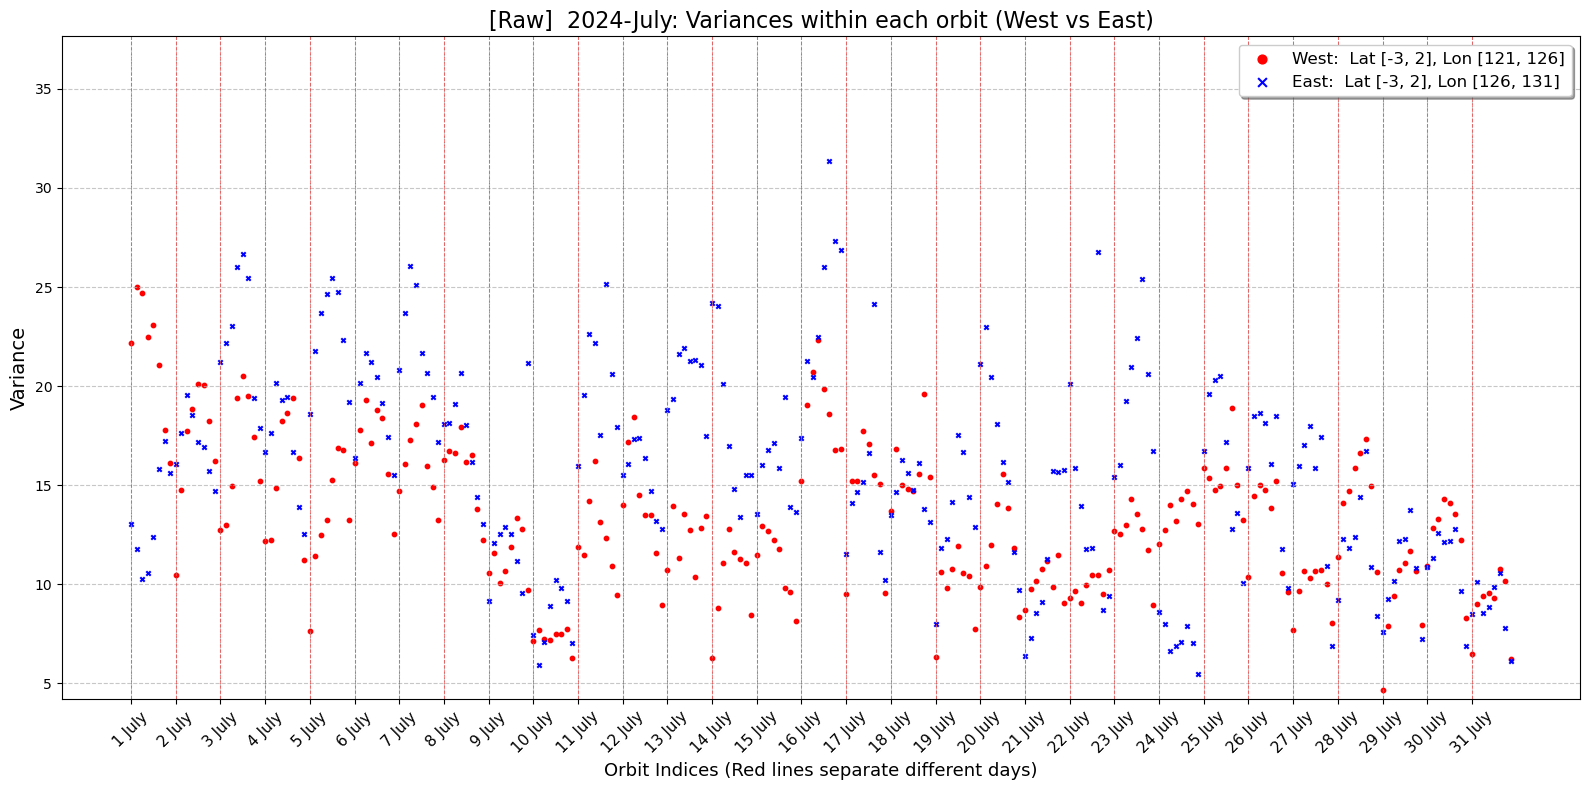

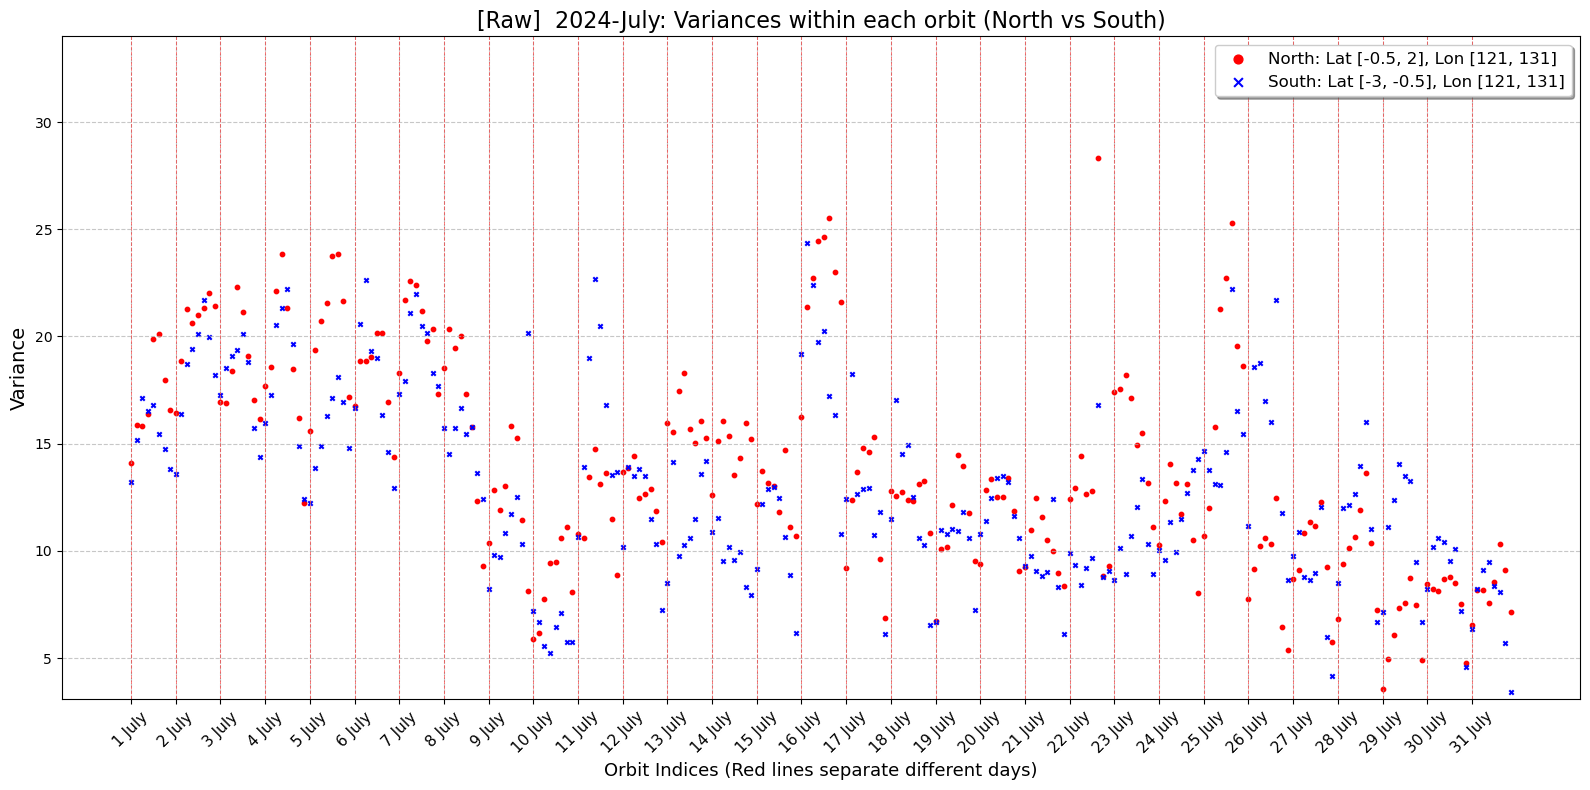

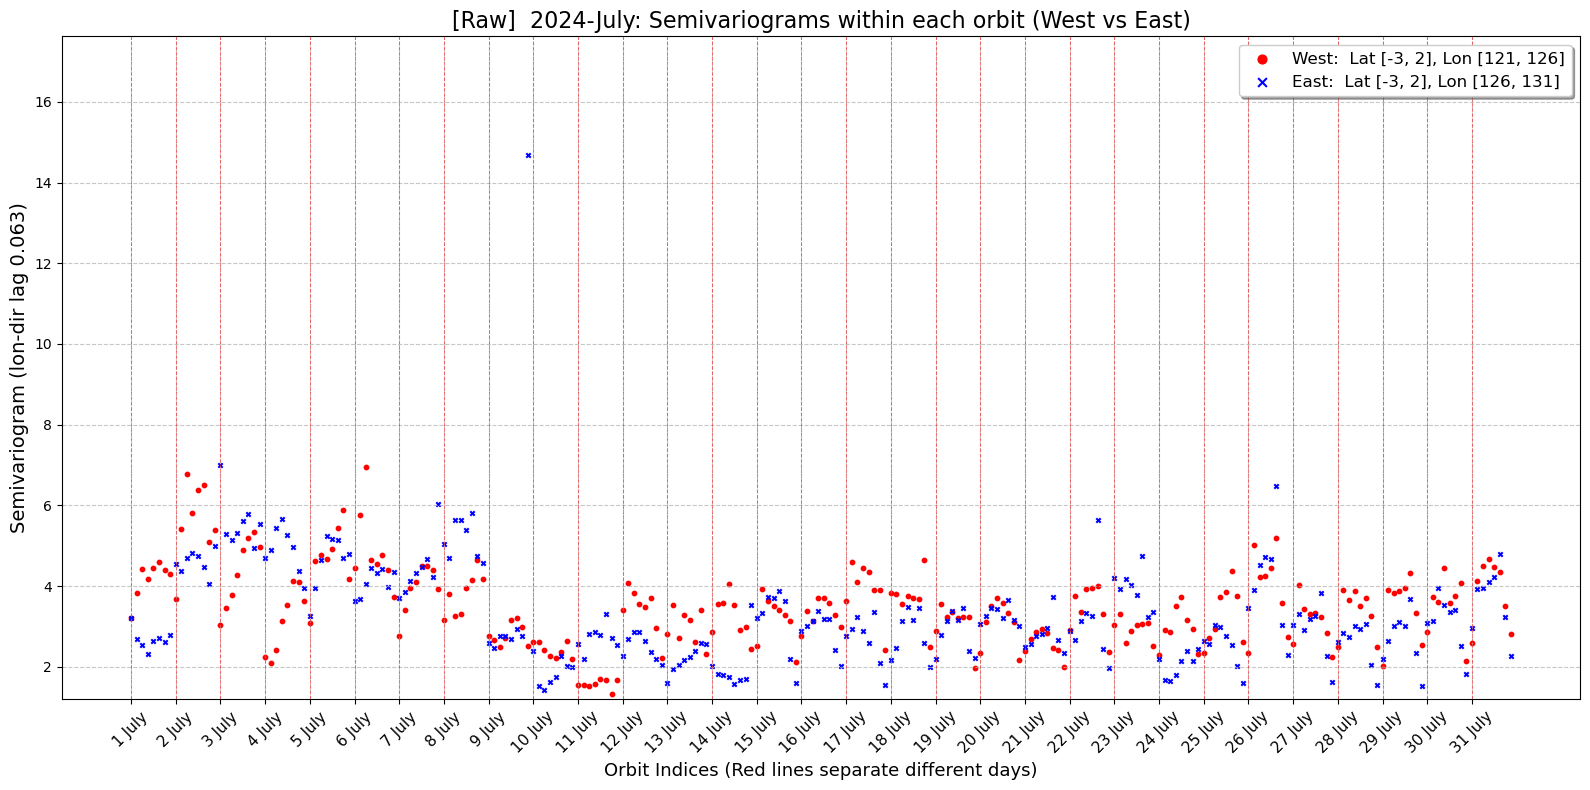

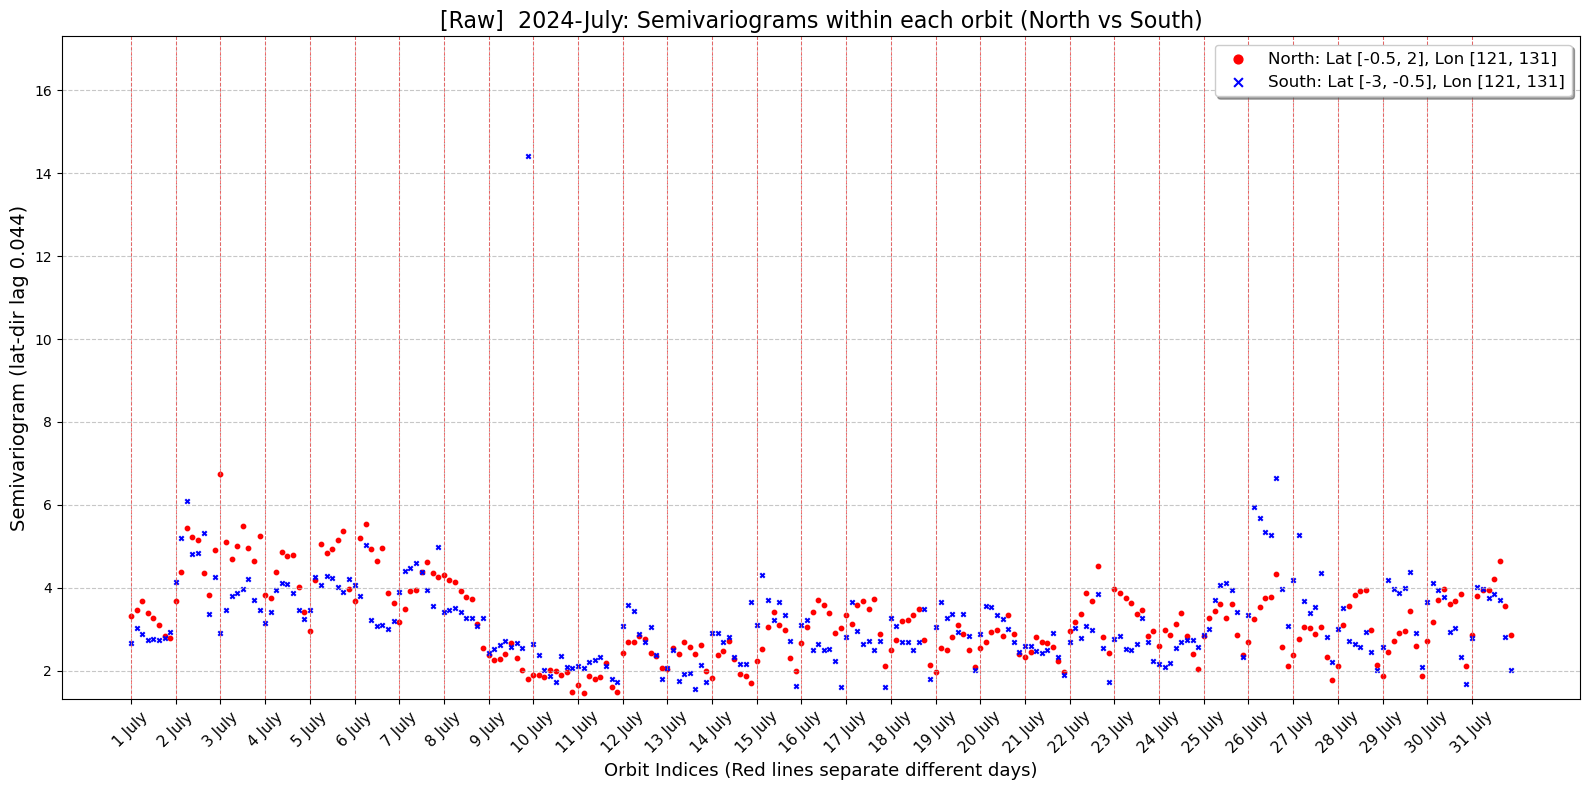

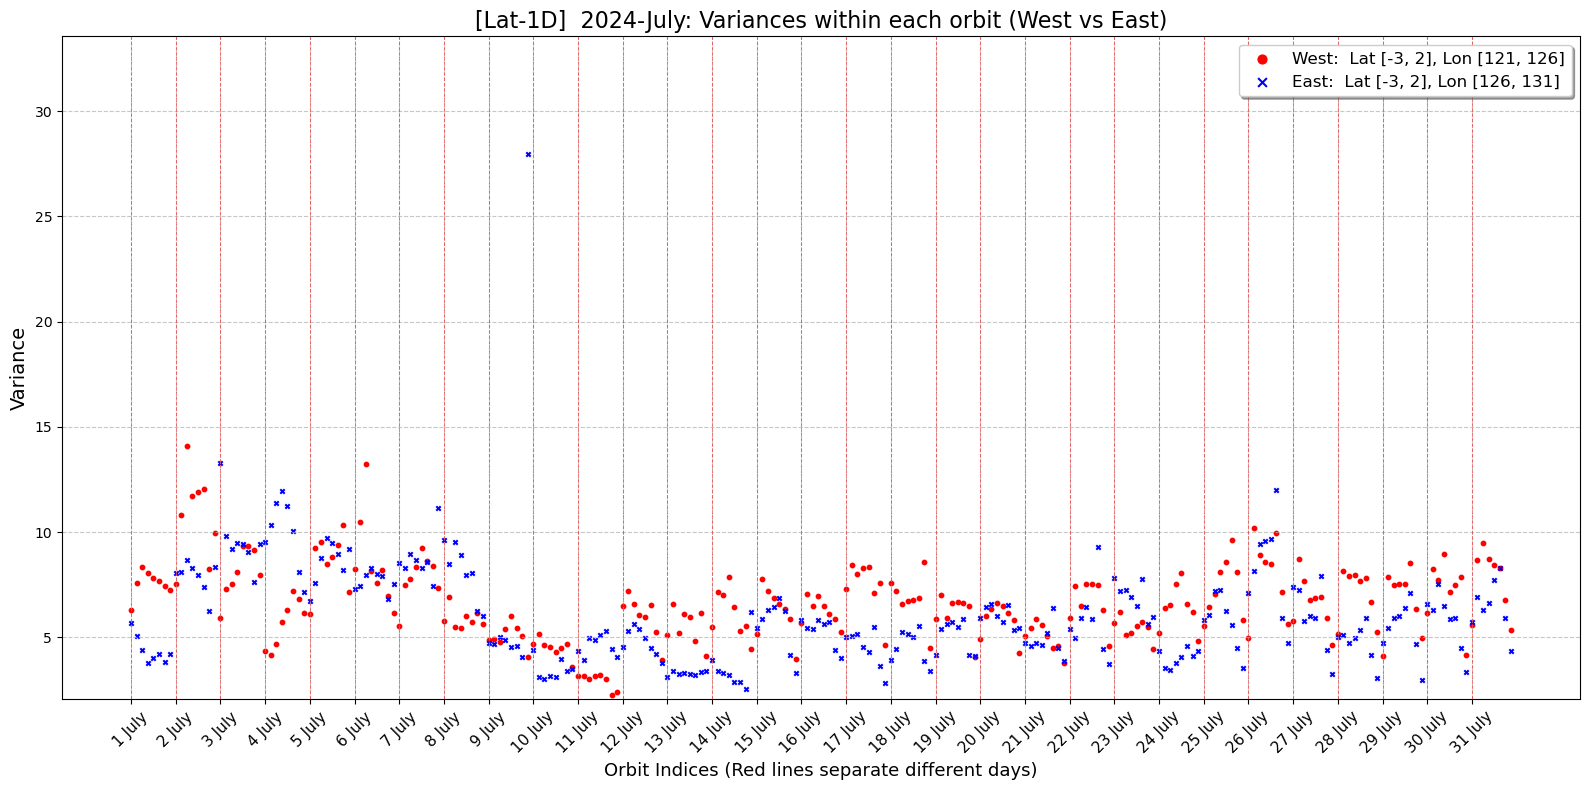

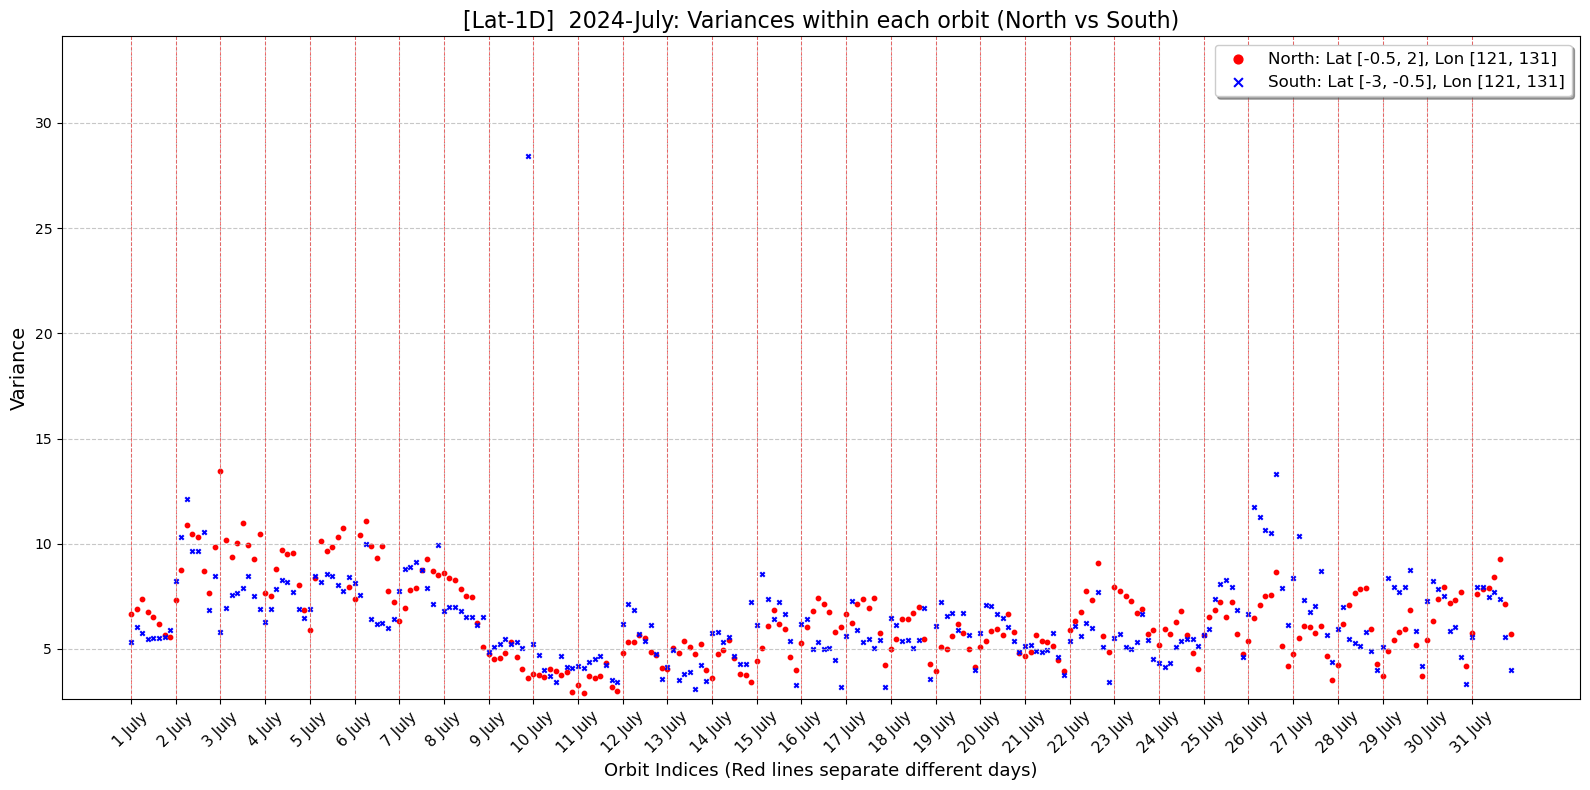

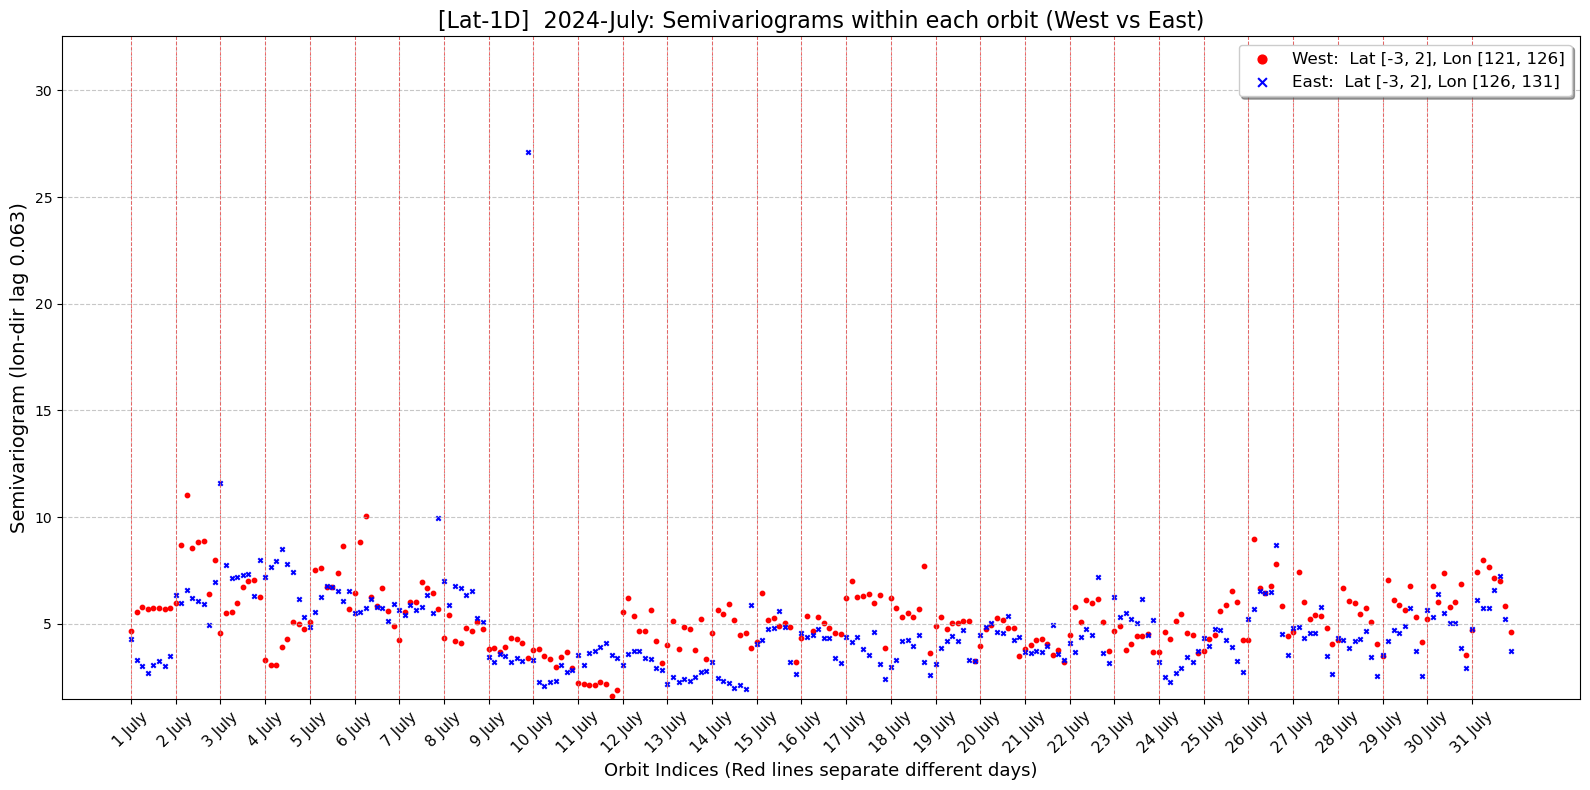

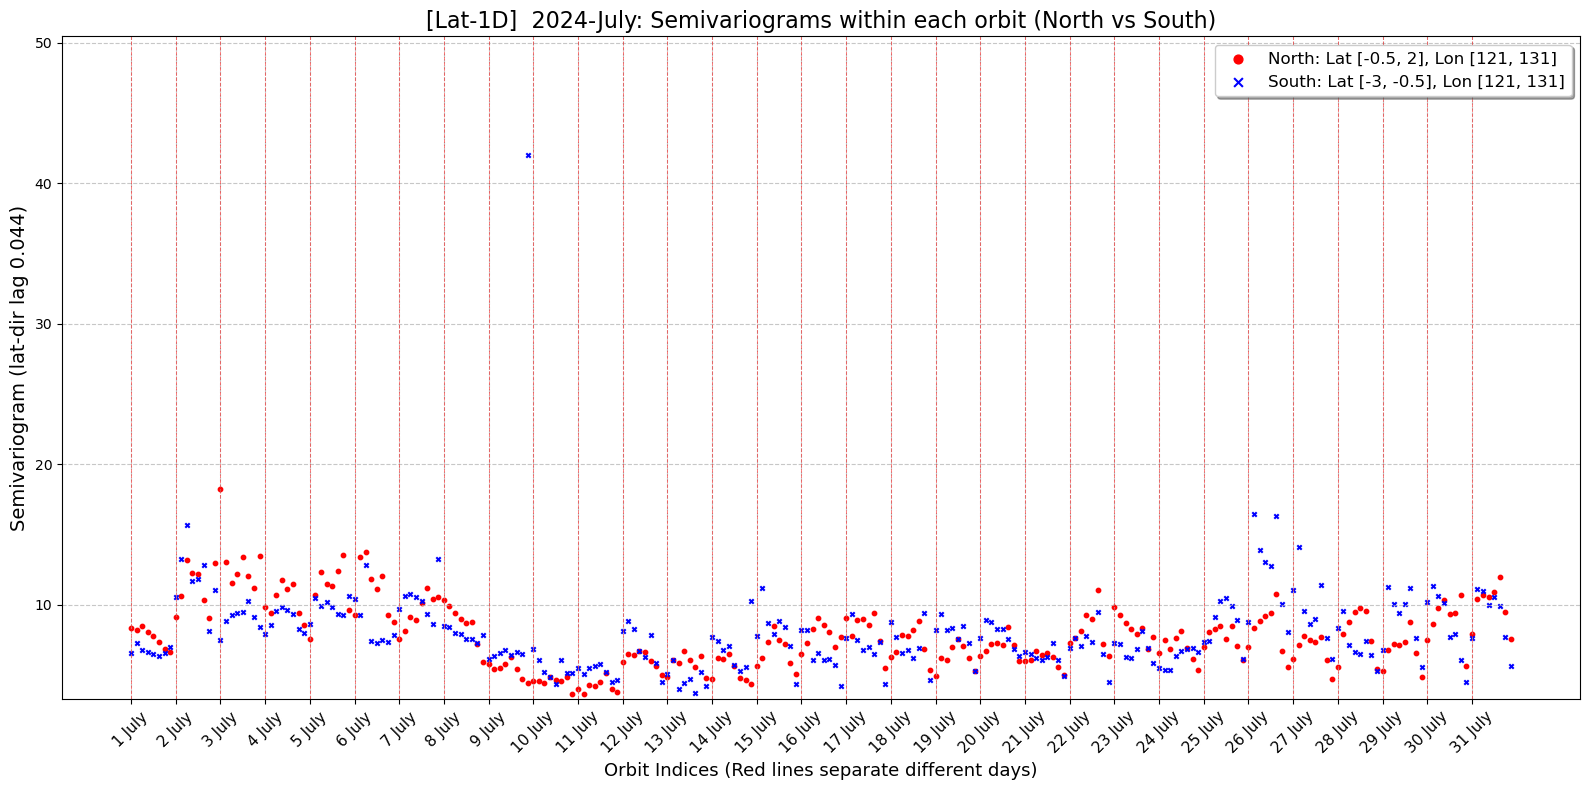

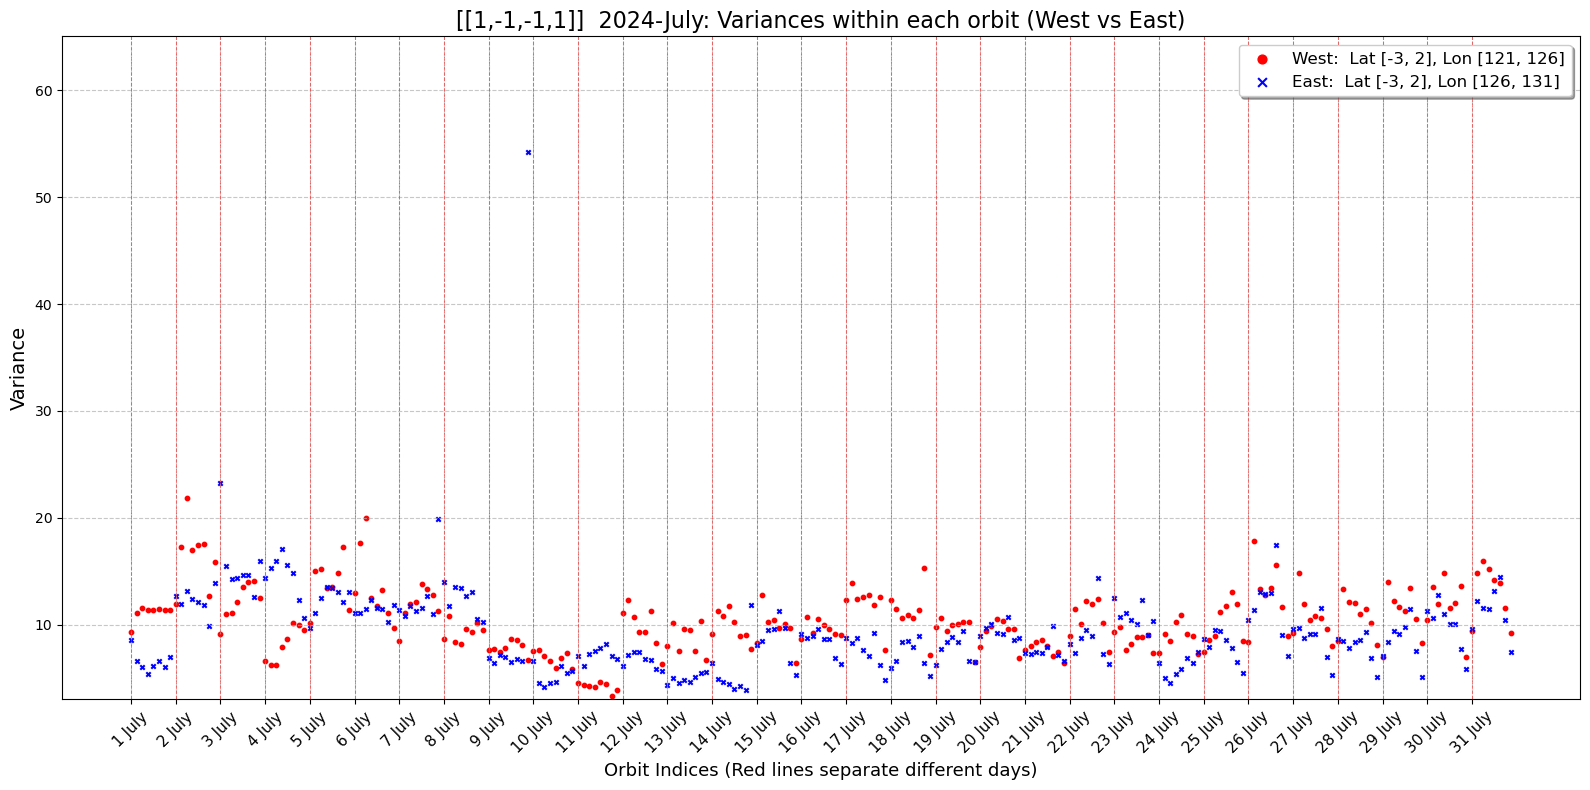

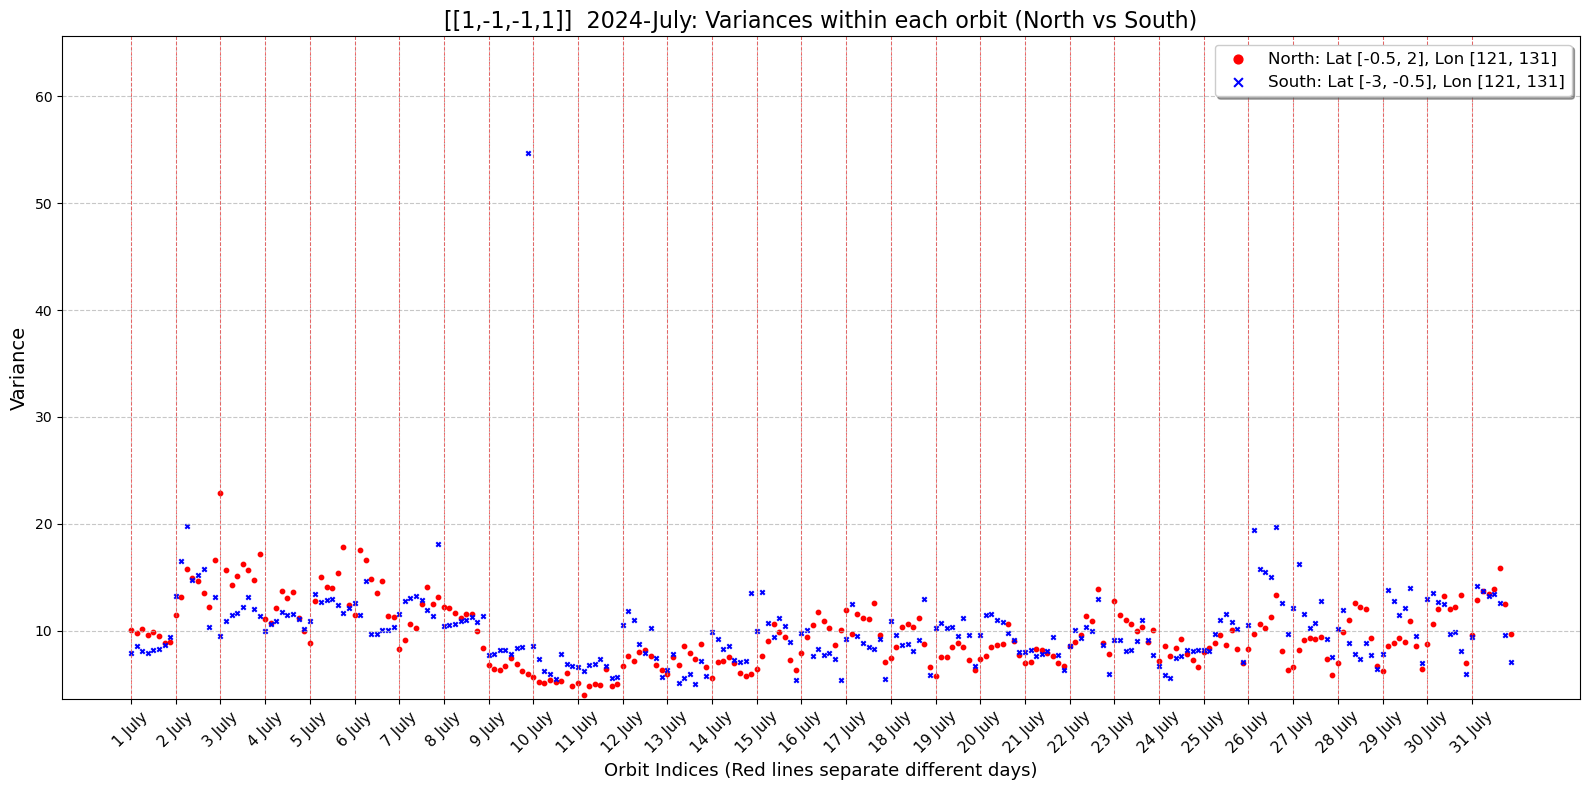

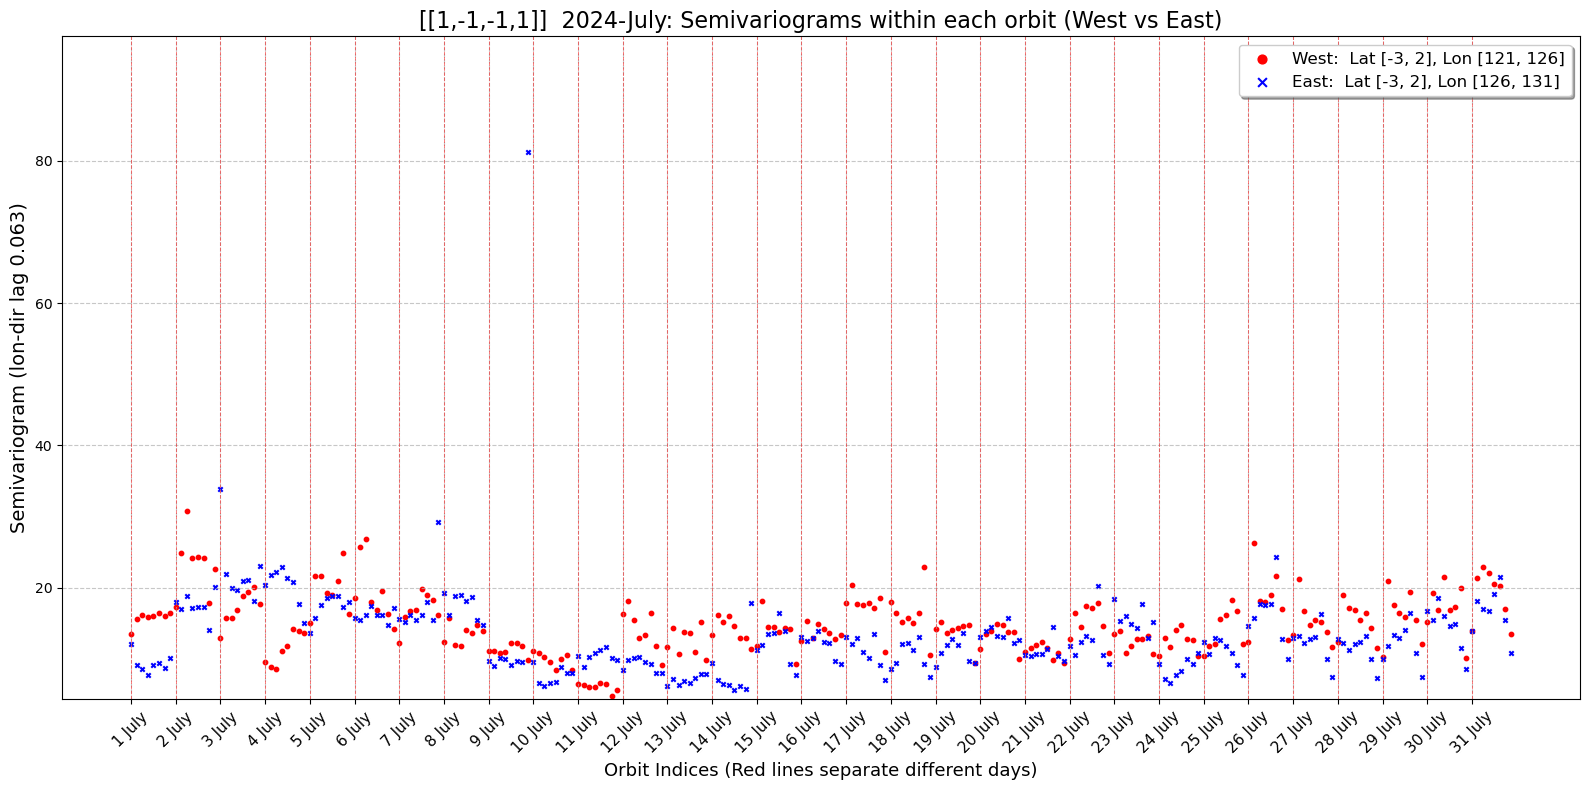

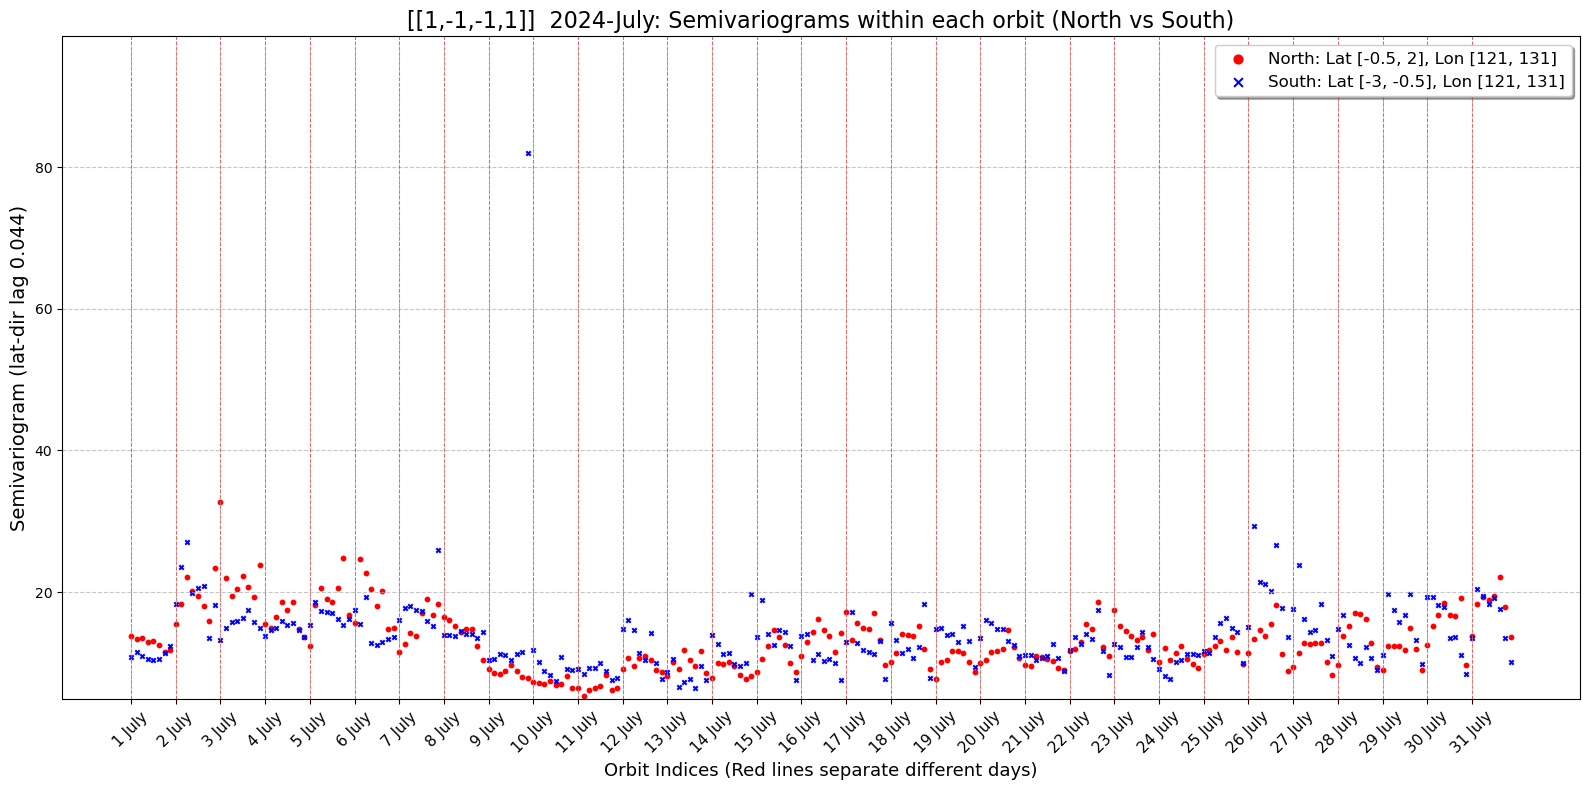

In [7]:
COLORS  = {'West': 'red',  'East': 'blue', 'North': 'red',  'South': 'blue'}
MARKERS = {'West': 'o',    'East': 'x',    'North': 'o',    'South': 'x'}
REGION_LABELS = {
    'West':  'West:  Lat {}, Lon [{}, {}]'.format(LAT_RANGE, LON_RANGE[0], int(lon_mid)),
    'East':  'East:  Lat {}, Lon [{}, {}]'.format(LAT_RANGE, int(lon_mid), LON_RANGE[1]),
    'North': 'North: Lat [{}, {}], Lon {}'.format(lat_mid, LAT_RANGE[1], LON_RANGE),
    'South': 'South: Lat [{}, {}], Lon {}'.format(LAT_RANGE[0], lat_mid, LON_RANGE),
}


def _make_plot(orb_idx, dpos, dlbl, y1, y2, r1, r2, ylabel, title, filter_name):
    tick_labels = ['{} {}'.format(lbl, MONTH_NAME) for lbl in dlbl]
    plt.figure(figsize=(16, 8))
    plt.scatter(orb_idx, y1, marker=MARKERS[r1], s=10,
                color=COLORS[r1], label=REGION_LABELS[r1])
    plt.scatter(orb_idx, y2, marker=MARKERS[r2], s=10,
                color=COLORS[r2], label=REGION_LABELS[r2])
    for pos in dpos:
        plt.axvline(x=pos, color='red', linestyle='--', linewidth=0.7, alpha=0.5)
    plt.xticks(ticks=dpos, labels=tick_labels, fontsize=11, rotation=45)
    plt.xlabel('Orbit Indices (Red lines separate different days)', fontsize=13)
    plt.ylabel(ylabel, fontsize=14)
    plt.title('[{}]  {}-{}: {}'.format(filter_name, YEARS[0], MONTH_NAME, title), fontsize=16)
    valid = [v for lst in [y1, y2] for v in lst if v is not None and not np.isnan(v)]
    if valid:
        plt.ylim([min(valid) * 0.9, max(valid) * 1.2])
    plt.grid(True, linestyle='--', alpha=0.7)
    plt.legend(fontsize=12, markerscale=2, loc='upper right', frameon=True, shadow=True)
    plt.tight_layout()
    plt.show()


for ver in ['Raw', 'Lat-1D', '[1,-1,-1,1]']:
    s    = stats[ver]
    orb  = s['orbit_indices']
    dpos = s['day_positions']
    dlbl = s['day_labels']
    v    = s['results']['var']
    sm   = s['results']['semi']

    _make_plot(orb, dpos, dlbl, v['West'],  v['East'],
               'West',  'East',  'Variance',
               'Variances within each orbit (West vs East)', ver)

    _make_plot(orb, dpos, dlbl, v['North'], v['South'],
               'North', 'South', 'Variance',
               'Variances within each orbit (North vs South)', ver)

    _make_plot(orb, dpos, dlbl, sm['West'],  sm['East'],
               'West',  'East',
               'Semivariogram (lon-dir lag {})'.format(LAG_LON),
               'Semivariograms within each orbit (West vs East)', ver)

    _make_plot(orb, dpos, dlbl, sm['North'], sm['South'],
               'North', 'South',
               'Semivariogram (lat-dir lag {})'.format(LAG_LAT),
               'Semivariograms within each orbit (North vs South)', ver)


In [ ]:
# ── Outlier diagnostic: [1,-1,-1,1] July 9 ───────────────────────────────
import re

diff11_map = maps['[1,-1,-1,1]']
s_diff11   = stats['[1,-1,-1,1]']

# 1. Find the outlier orbit(s): day=9, highest variance in any region
sorted_keys_d = sorted(diff11_map.keys())
day9_keys = [k for k in sorted_keys_d
             if re.search(r'day09', k)]
print('Day-9 orbit keys:', day9_keys)
print()

# 2. Variance per orbit for day 9 — all 4 regions
print(f'{"key":45s}  {"west":>8s}  {"east":>8s}  {"north":>8s}  {"south":>8s}')
print('-'*85)
for k in day9_keys:
    df = diff11_map[k]
    w = _sub(df, LAT_RANGE[0], LAT_RANGE[1], LON_RANGE[0], lon_mid)
    e = _sub(df, LAT_RANGE[0], LAT_RANGE[1], lon_mid,       LON_RANGE[1])
    n = _sub(df, lat_mid,       LAT_RANGE[1], LON_RANGE[0], LON_RANGE[1])
    s = _sub(df, LAT_RANGE[0],  lat_mid,      LON_RANGE[0], LON_RANGE[1])
    vw = np.var(w.ColumnAmountO3) if len(w)>=10 else np.nan
    ve = np.var(e.ColumnAmountO3) if len(e)>=10 else np.nan
    vn = np.var(n.ColumnAmountO3) if len(n)>=10 else np.nan
    vs = np.var(s.ColumnAmountO3) if len(s)>=10 else np.nan
    print(f'{k:45s}  {vw:8.3f}  {ve:8.3f}  {vn:8.3f}  {vs:8.3f}')

print()
# 3. Compare with raw day 9 variance
raw_map = maps['Raw']
print('--- Raw data day-9 variance ---')
print(f'{"key":45s}  {"west":>8s}  {"east":>8s}  {"north":>8s}  {"south":>8s}')
print('-'*85)
day9_raw = [k for k in sorted(raw_map.keys()) if re.search(r'day09', k)]
for k in day9_raw:
    df = raw_map[k]
    w = _sub(df, LAT_RANGE[0], LAT_RANGE[1], LON_RANGE[0], lon_mid)
    e = _sub(df, LAT_RANGE[0], LAT_RANGE[1], lon_mid,       LON_RANGE[1])
    n = _sub(df, lat_mid,       LAT_RANGE[1], LON_RANGE[0], LON_RANGE[1])
    s = _sub(df, LAT_RANGE[0],  lat_mid,      LON_RANGE[0], LON_RANGE[1])
    vw = np.var(w.ColumnAmountO3) if len(w)>=10 else np.nan
    ve = np.var(e.ColumnAmountO3) if len(e)>=10 else np.nan
    vn = np.var(n.ColumnAmountO3) if len(n)>=10 else np.nan
    vs = np.var(s.ColumnAmountO3) if len(s)>=10 else np.nan
    print(f'{k:45s}  {vw:8.3f}  {ve:8.3f}  {vn:8.3f}  {vs:8.3f}')

print()
# 4. Find the worst orbit and inspect extreme values
print('--- Extreme ColumnAmountO3 in [1,-1,-1,1] day-9 (full orbit) ---')
for k in day9_keys:
    df = diff11_map[k]
    vals = df['ColumnAmountO3'].dropna()
    q99  = vals.quantile(0.99)
    q01  = vals.quantile(0.01)
    print(f'{k[-20:]}  n={len(vals):5d}  min={vals.min():9.3f}  '
          f'max={vals.max():9.3f}  q1%={q01:7.3f}  q99%={q99:7.3f}  '
          f'std={vals.std():.3f}')

print()
# 5. Check if outlier is in a specific lat/lon region
print('--- Top 10 extreme values in worst day-9 [1,-1,-1,1] orbit ---')
worst_key = max(day9_keys,
    key=lambda k: np.nanmax([
        np.var(_sub(diff11_map[k], r[0], r[1], r[2], r[3])['ColumnAmountO3'])
        if len(_sub(diff11_map[k], r[0], r[1], r[2], r[3])) >= 10 else 0
        for r in [[-3,2,121,126],[-3,2,126,131],[-0.5,2,121,131],[-3,-0.5,121,131]]
    ])
)
print('Worst orbit:', worst_key)
df_w = diff11_map[worst_key].dropna(subset=['ColumnAmountO3'])
print(df_w.nlargest(10, 'ColumnAmountO3')[['Latitude','Longitude','ColumnAmountO3']])
print()
print(df_w.nsmallest(10, 'ColumnAmountO3')[['Latitude','Longitude','ColumnAmountO3']])

print()
# 6. Compare with raw orbit at same time — is it in the raw data too?
print('--- Corresponding raw orbit extreme values ---')
df_raw_w = raw_map[worst_key].dropna(subset=['ColumnAmountO3'])
print('Raw orbit stats:  min={:.3f}  max={:.3f}  std={:.3f}'.format(
    df_raw_w.ColumnAmountO3.min(), df_raw_w.ColumnAmountO3.max(), df_raw_w.ColumnAmountO3.std()))
print(df_raw_w.nlargest(5,'ColumnAmountO3')[['Latitude','Longitude','ColumnAmountO3']])
print(df_raw_w.nsmallest(5,'ColumnAmountO3')[['Latitude','Longitude','ColumnAmountO3']])


Pooled: 4,382,600 obs | lat_mean=-0.483 | lon_mean=126.028

v1 (lat+time):          R²=0.1410  residual var=20.8768
v2 (lat+lon+lon²+time): R²=0.1430  residual var=20.8275

v2 beta:
  intercept    = +258.1932
  lat          = +1.0543
  lon          = -0.0293
  lon²         = +0.0275
  hour=1       = -0.5254
  hour=2       = -1.3434
  hour=3       = -1.5756
  hour=4       = -1.3768
  hour=5       = -0.6653
  hour=6       = -0.1168
  hour=7       = +1.8624


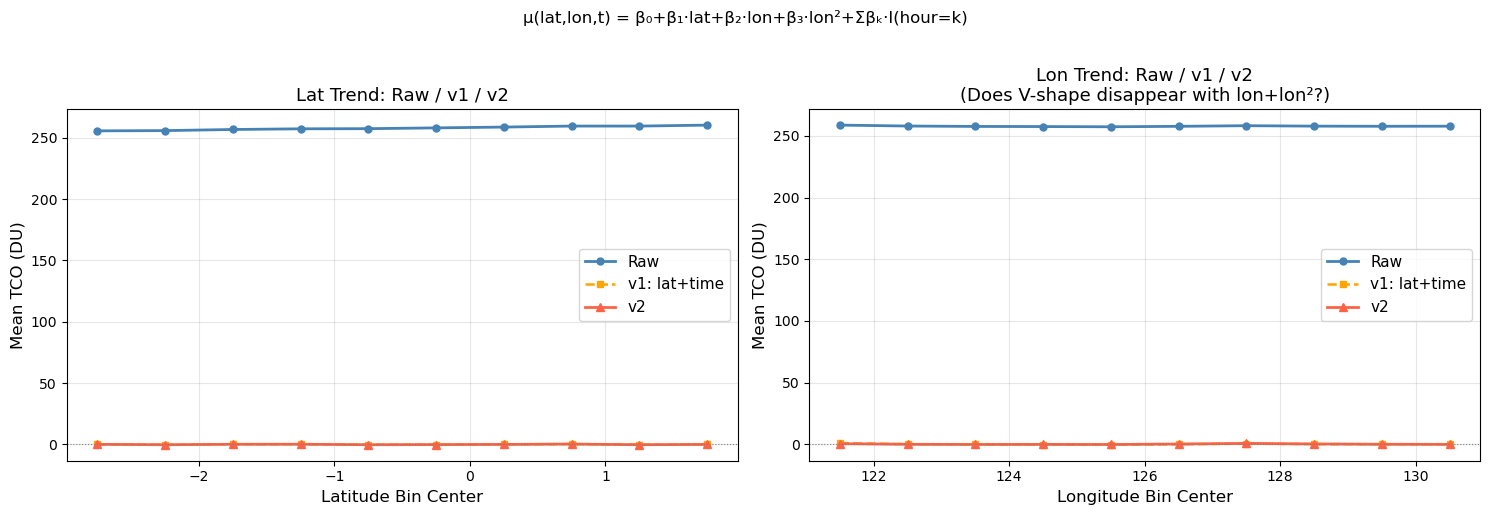


Running stationarity on v2 residuals...


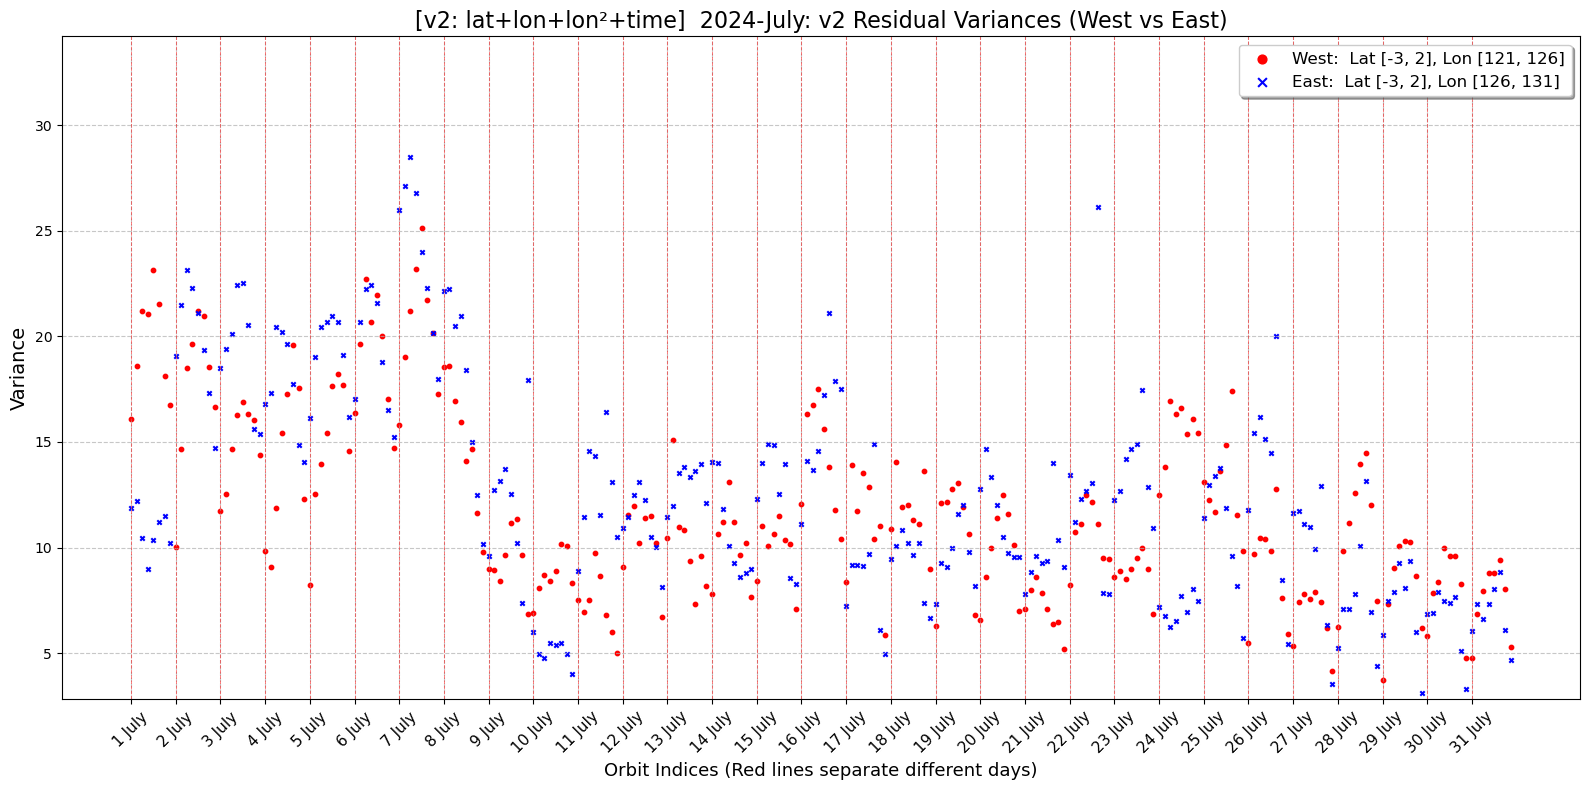

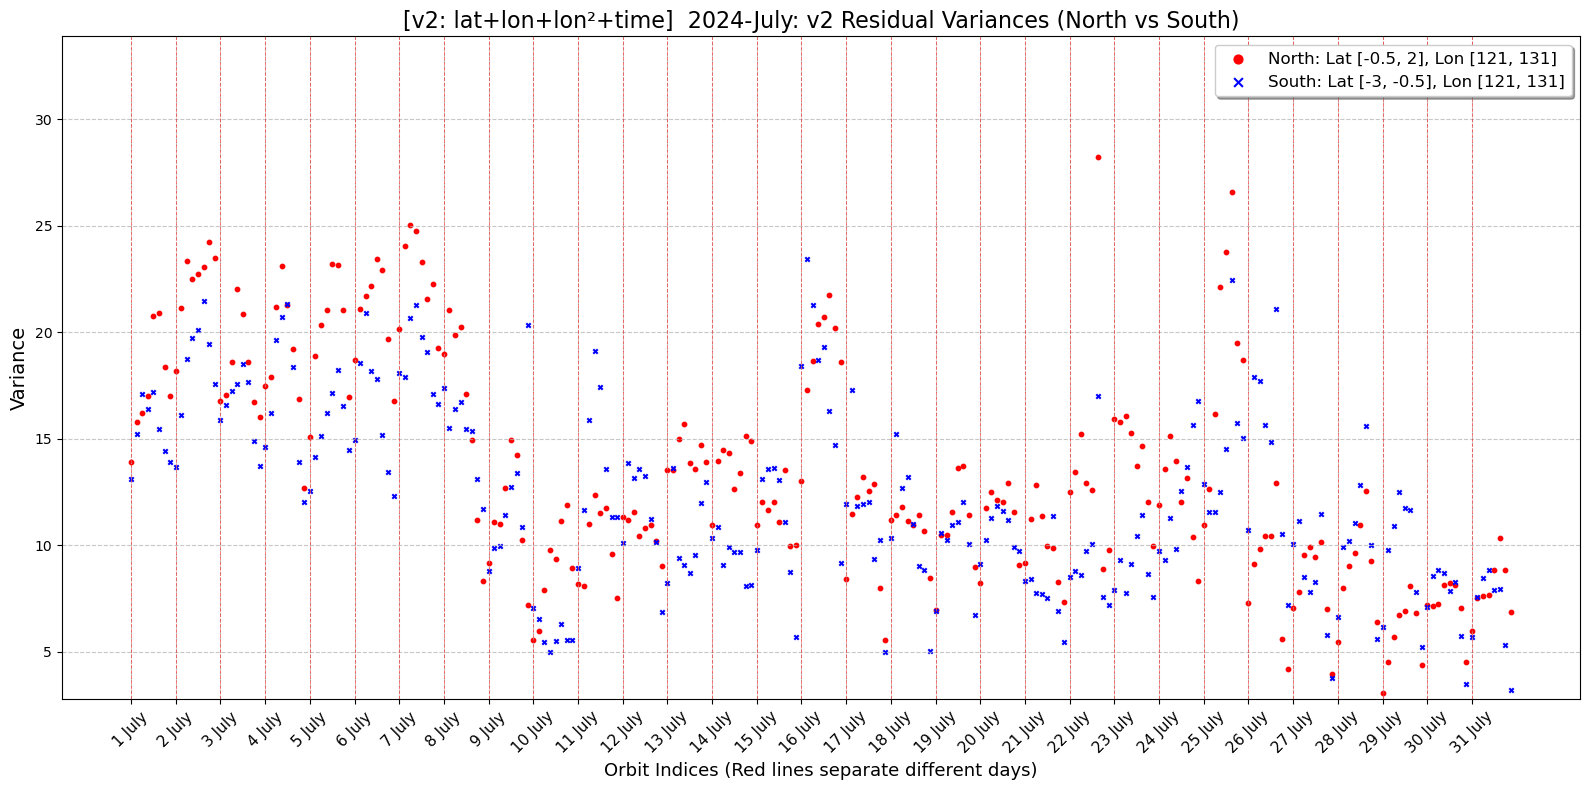

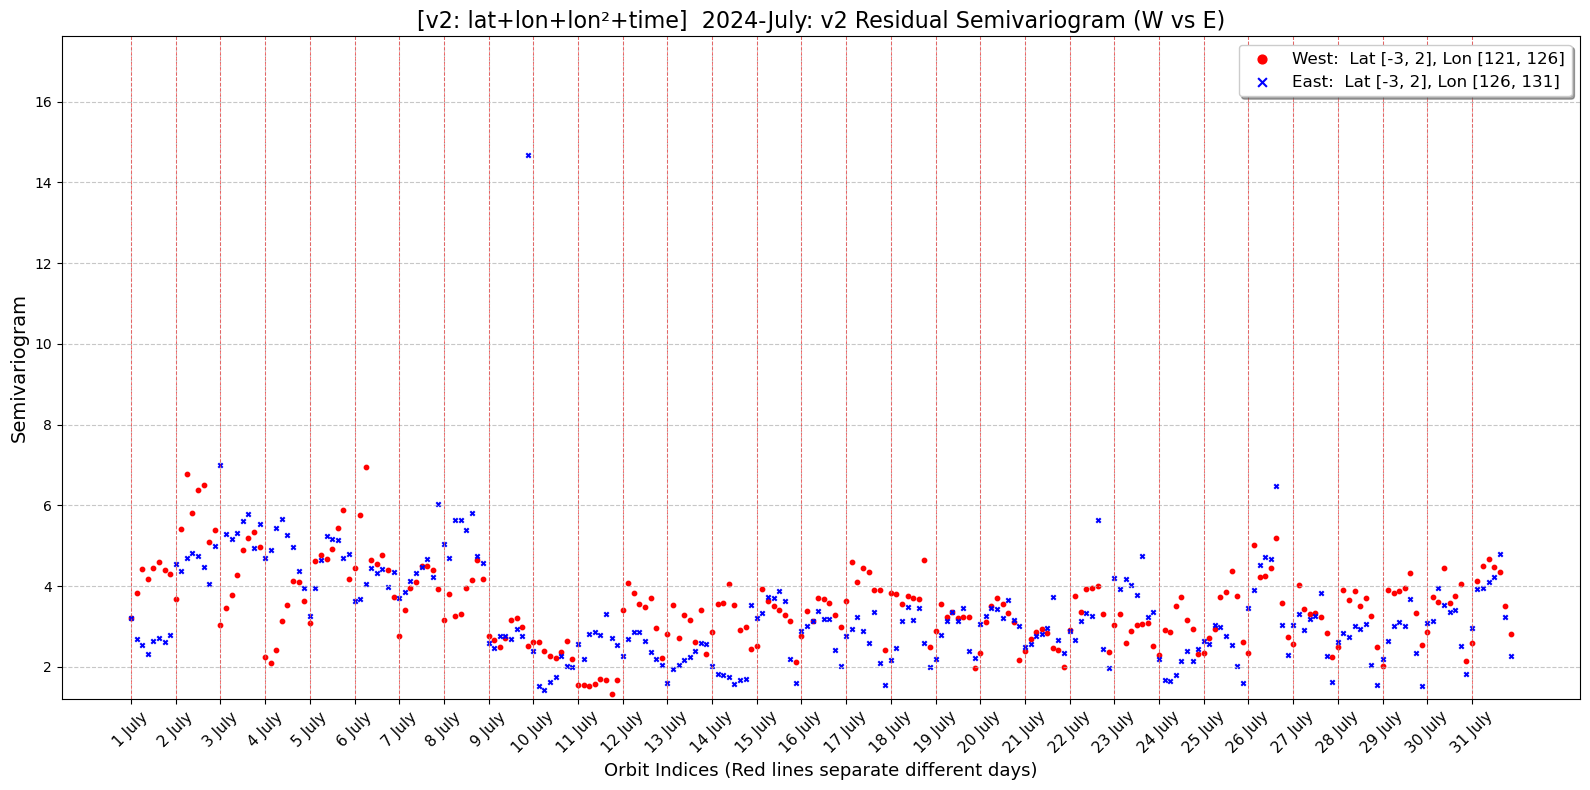

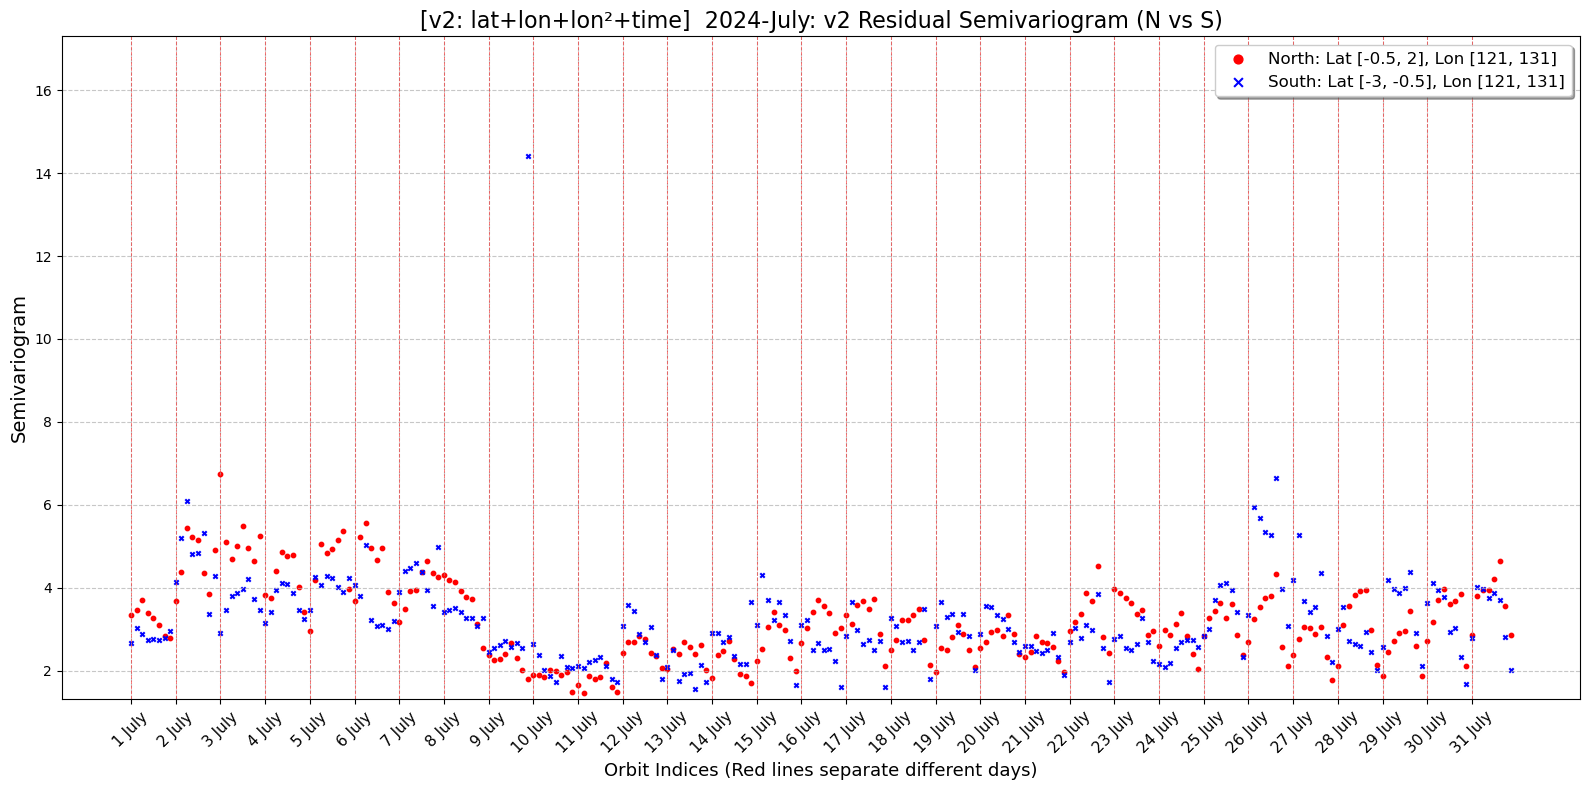

In [11]:
# ═══════════════════════════════════════════════════════════════════════════
# GLS-style mean removal  —  v2: lon linear + quadratic added
#   μ(lat, lon, t) = β₀ + β₁·lat + β₂·lon + β₃·lon² + Σβₖ·I(hour=k)
# Compare v1 (lat+time only) vs v2 (lat+lon+lon²+time)
# ═══════════════════════════════════════════════════════════════════════════
import numpy as np
import matplotlib.pyplot as plt

# ── 1. Pool all orbits ────────────────────────────────────────────────────
records = []
for key in sorted(df_map.keys()):
    df   = df_map[key]
    date = _parse_key_date(key)
    if pd.isna(date): continue
    sub  = df.dropna(subset=['ColumnAmountO3']).copy()
    sub['hour_slot'] = date.hour
    records.append(sub)

df_pool = pd.concat(records, ignore_index=True)
hour_slots   = sorted(df_pool['hour_slot'].unique())
lat_mean_val = df_pool['Latitude'].mean()
lon_mean_val = df_pool['Longitude'].mean()
print(f'Pooled: {len(df_pool):,} obs | lat_mean={lat_mean_val:.3f} | lon_mean={lon_mean_val:.3f}')


def build_X(lat, lon, hour_arr, hour_slots, lat_mean, lon_mean, include_lon=True):
    """Build design matrix.  include_lon=False → v1 (lat+time only)."""
    parts = [
        np.ones(len(lat)),
        lat - lat_mean,
    ]
    if include_lon:
        lc = lon - lon_mean
        parts += [lc, lc ** 2]          # lon linear + quadratic
    for h in hour_slots[1:]:
        parts.append((hour_arr == h).astype(float))
    return np.column_stack(parts)


def fit_ols(df_in, hour_slots, lat_mean, lon_mean, include_lon):
    X = build_X(df_in['Latitude'].values, df_in['Longitude'].values,
                df_in['hour_slot'].values, hour_slots,
                lat_mean, lon_mean, include_lon)
    y = df_in['ColumnAmountO3'].values
    beta, _, _, _ = np.linalg.lstsq(X, y, rcond=None)
    mu   = X @ beta
    resid = y - mu
    r2   = 1 - np.var(resid) / np.var(y)
    return beta, mu, resid, r2


# ── 2. Fit v1 and v2 ──────────────────────────────────────────────────────
beta_v1, mu_v1, res_v1, r2_v1 = fit_ols(df_pool, hour_slots,
                                          lat_mean_val, lon_mean_val, include_lon=False)
beta_v2, mu_v2, res_v2, r2_v2 = fit_ols(df_pool, hour_slots,
                                          lat_mean_val, lon_mean_val, include_lon=True)

df_pool['resid_v1'] = res_v1
df_pool['resid_v2'] = res_v2

print(f'\nv1 (lat+time):          R²={r2_v1:.4f}  residual var={np.var(res_v1):.4f}')
print(f'v2 (lat+lon+lon²+time): R²={r2_v2:.4f}  residual var={np.var(res_v2):.4f}')
print(f'\nv2 beta:')
labels = ['intercept', 'lat', 'lon', 'lon²'] + [f'hour={h}' for h in hour_slots[1:]]
for lbl, b in zip(labels, beta_v2):
    print(f'  {lbl:12s} = {b:+.4f}')

# ── 3. Spatial trend comparison plot ─────────────────────────────────────
LAT_EDGES = np.arange(-3, 2.5, 0.5)
LON_EDGES = np.arange(121, 132, 1.0)
LAT_CTRS  = (LAT_EDGES[:-1] + LAT_EDGES[1:]) / 2
LON_CTRS  = (LON_EDGES[:-1] + LON_EDGES[1:]) / 2

def bin_mean(df_in, col, edges, var):
    labels = (edges[:-1] + edges[1:]) / 2
    df_in  = df_in.copy()
    df_in['bin'] = pd.cut(df_in[var], bins=edges, labels=labels)
    return df_in.groupby('bin', observed=True)[col].mean()

fig, axes = plt.subplots(1, 2, figsize=(15, 5))
styles = {
    'Raw':    ('steelblue', 'o-',  2.0),
    'v1':     ('orange',   's--', 1.8),
    'v2':     ('tomato',   '^-',  2.0),
}
cols = {'Raw': 'ColumnAmountO3', 'v1': 'resid_v1', 'v2': 'resid_v2'}

for ax, (var, edges, ctrs, xlabel) in zip(axes, [
    ('Latitude',  LAT_EDGES, LAT_CTRS, 'Latitude Bin Center'),
    ('Longitude', LON_EDGES, LON_CTRS, 'Longitude Bin Center'),
]):
    for label, (color, ls, lw) in styles.items():
        trend = bin_mean(df_pool, cols[label], edges, var)
        ax.plot(trend.index.astype(float), trend.values,
                ls, color=color, linewidth=lw,
                label=label if label != 'v1' else 'v1: lat+time',
                markersize=6 if label == 'v2' else 5)
    ax.axhline(0, color='gray', linestyle=':', linewidth=0.8)
    ax.set_xlabel(xlabel, fontsize=12)
    ax.set_ylabel('Mean TCO (DU)', fontsize=12)
    ax.legend(fontsize=11)
    ax.grid(True, alpha=0.3)

axes[0].set_title('Lat Trend: Raw / v1 / v2', fontsize=13)
axes[1].set_title('Lon Trend: Raw / v1 / v2\n(Does V-shape disappear with lon+lon²?)', fontsize=13)
plt.suptitle('μ(lat,lon,t) = β₀+β₁·lat+β₂·lon+β₃·lon²+Σβₖ·I(hour=k)',
             fontsize=12, y=1.02)
plt.tight_layout()
plt.show()

# ── 4. Rebuild df_map for v2 residuals ───────────────────────────────────
df_map_residual_v2 = {}
for key in sorted(df_map.keys()):
    df   = df_map[key]
    date = _parse_key_date(key)
    if pd.isna(date): continue
    sub  = df.dropna(subset=['ColumnAmountO3']).copy()
    h    = date.hour
    hour_arr = np.full(len(sub), h)
    X_orb = build_X(sub['Latitude'].values, sub['Longitude'].values,
                    hour_arr, hour_slots, lat_mean_val, lon_mean_val, include_lon=True)
    sub['ColumnAmountO3'] = sub['ColumnAmountO3'].values - X_orb @ beta_v2
    df_map_residual_v2[key] = sub[['Latitude','Longitude','ColumnAmountO3']].reset_index(drop=True)

# ── 5. Stationarity on v2 residuals ──────────────────────────────────────
print('\nRunning stationarity on v2 residuals...')
orb_r2, dpos_r2, dlbl_r2, res_r2 = compute_stats(df_map_residual_v2)

for title, r1, r2, col_sfx, ylabel in [
    ('v2 Residual Variances (West vs East)',   'West',  'East',  'var',  'Variance'),
    ('v2 Residual Variances (North vs South)', 'North', 'South', 'var',  'Variance'),
    ('v2 Residual Semivariogram (W vs E)',     'West',  'East',  'semi', 'Semivariogram'),
    ('v2 Residual Semivariogram (N vs S)',     'North', 'South', 'semi', 'Semivariogram'),
]:
    _make_plot(orb_r2, dpos_r2, dlbl_r2,
               res_r2[col_sfx][r1], res_r2[col_sfx][r2],
               r1, r2, ylabel, title, 'v2: lat+lon+lon²+time')
